<a href="https://colab.research.google.com/github/Sandeep-reddy-2811/AI-driven-SkillMap/blob/main/House_Price_predicting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

ds = pd.read_excel("/content/HousePricePrediction.xlsx")
print(ds.head(5))

   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  


In [3]:
object_cols = ds.select_dtypes(include=['object']).columns
print("Object Columns: ", len(object_cols))

#Return a subset of the DataFrame's columns based on the column dtypes

int_cols = ds.select_dtypes(include=['int64']).columns
print("Integer Columns: ", len(int_cols))

float_cols = ds.select_dtypes(include=['float64']).columns
print("Float Columns: ", len(float_cols))

Object Columns:  4
Integer Columns:  6
Float Columns:  3


Heat Map Saved


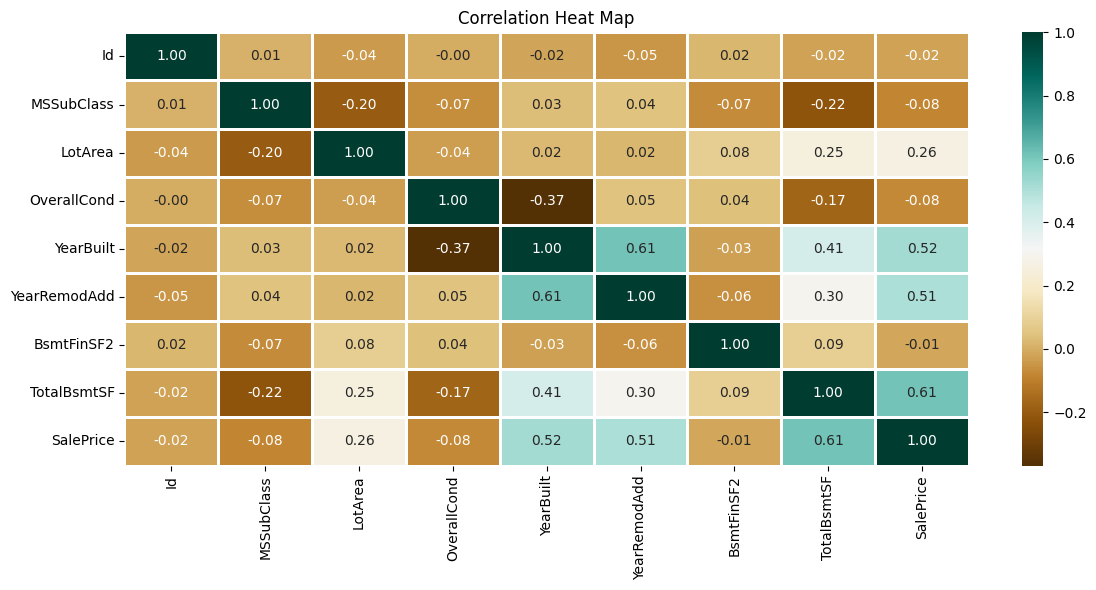

In [4]:
num_dataset = ds.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 6))
sb.heatmap(num_dataset.corr(),
           cmap = 'BrBG',
           fmt = '.2f',
           linewidths = '1',
           annot = True)

'''heatmap() = Plot rectangular data as a color-encoded matrix.
This is an Axes-level function and will draw the heatmap into the
currently-active Axes if none is provided to the ax argument.  Part of
this Axes space will be taken and used to plot a colormap, unless cbar
is False or a separate Axes is provided to cbar_ax.'''

plt.title("Correlation Heat Map")
plt.tight_layout()
plt.savefig("CorrelationHeatMap.png")
print("Heat Map Saved")

<Axes: title={'center': 'Number of unique values of features'}, xlabel='None'>

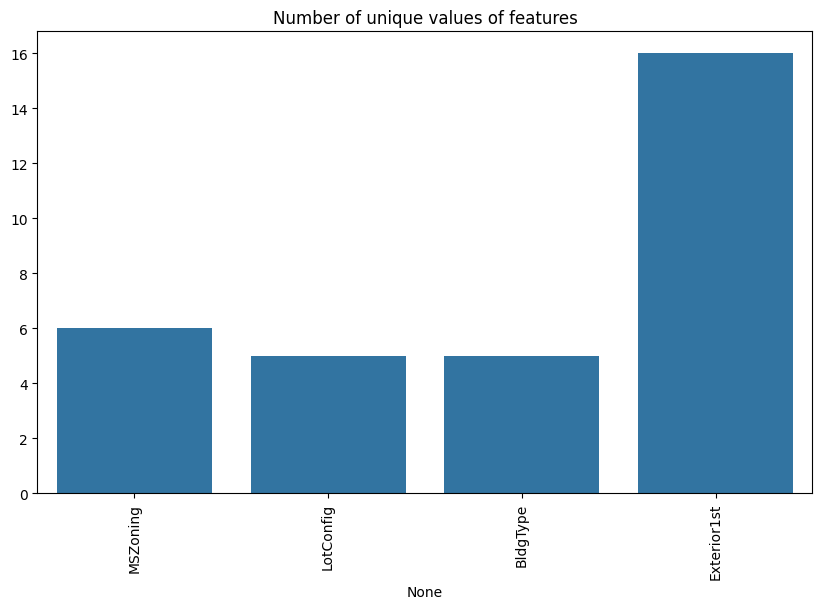

In [5]:
unique_values = []

for col in object_cols:
  unique_values.append(ds[col].unique().size)

plt.figure(figsize=[10, 6])
plt.title("Number of unique values of features")
plt.xticks(rotation=90)
sb.barplot(x=object_cols, y=unique_values)

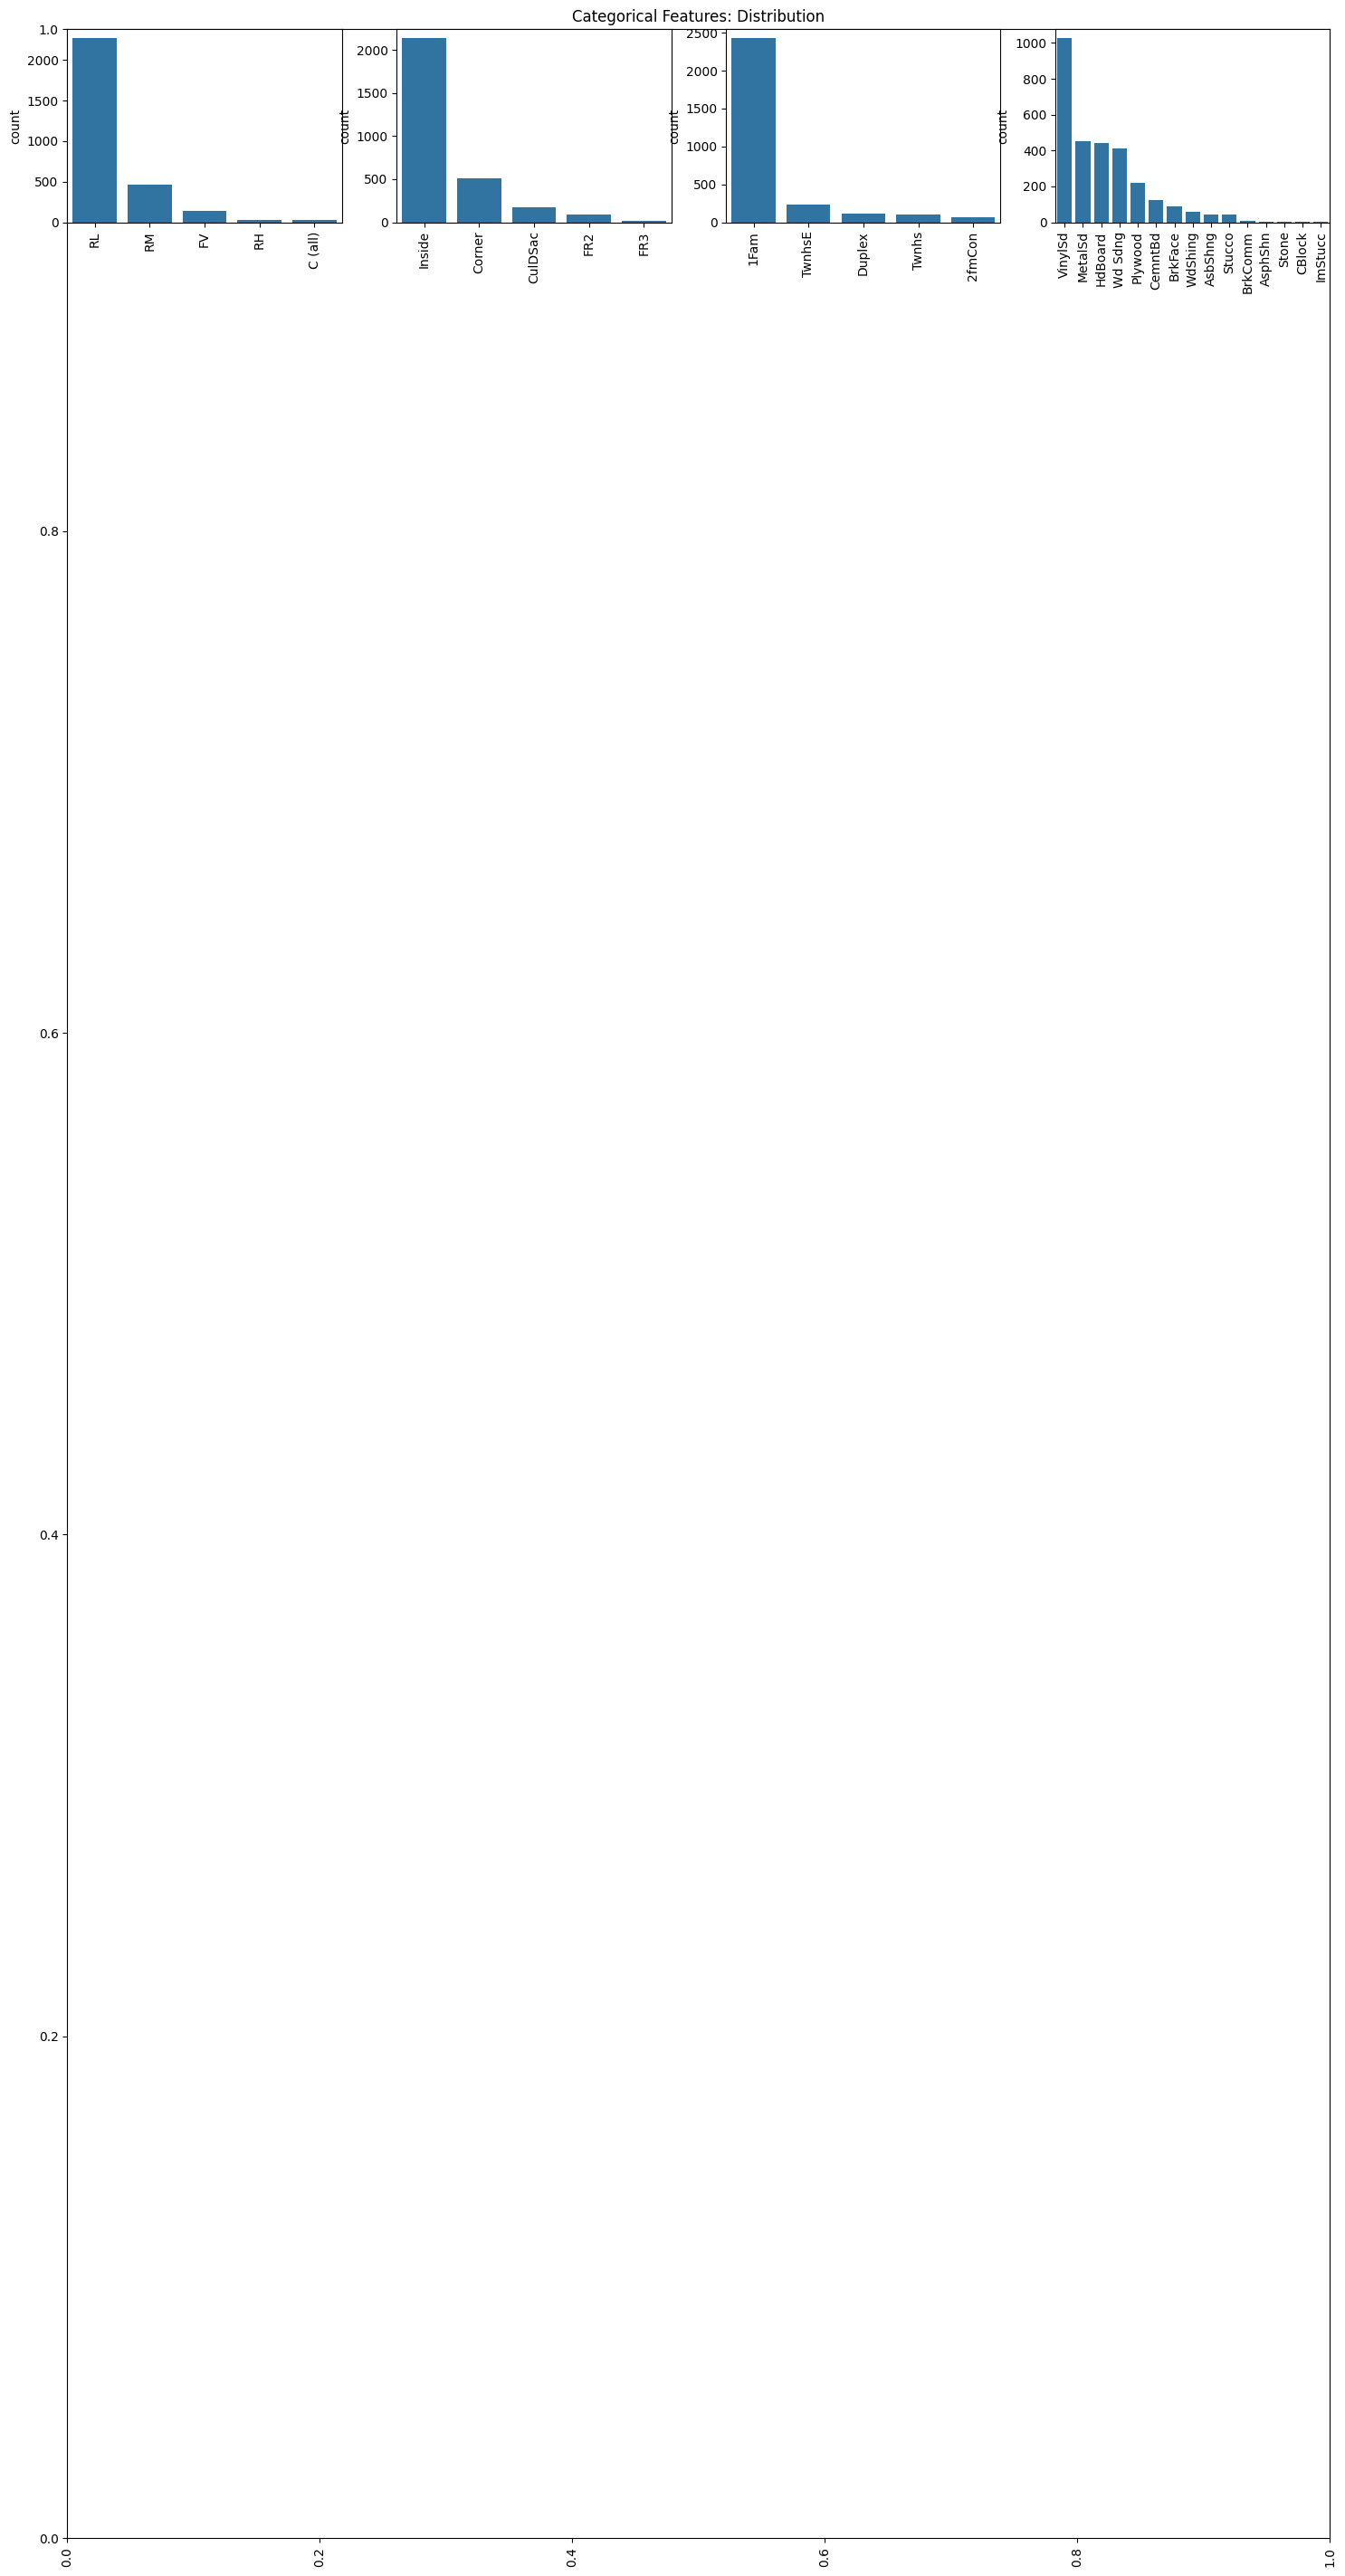

In [6]:
plt.figure(figsize=(18, 36))
plt.title("Categorical Features: Distribution")
plt.xticks(rotation=90)
index = 1

for col in object_cols:
    y = ds[col].value_counts()
    plt.subplot(11, 4, index)
    plt.xticks(rotation=90)
    sb.barplot(x=list(y.index), y=y)
    index += 1

In [7]:
ds['SalePrice'] = ds['SalePrice'].fillna(ds['SalePrice'].mean())
new_ds = ds.dropna()
new_ds.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotArea,0
LotConfig,0
BldgType,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
Exterior1st,0


In [8]:
s = (new_ds.dtypes =='object')
object_cols = list(s[s].index)
print("Categorical Variables: ")
print(object_cols)
print("No of categorical features: ",len(object_cols))

Categorical Variables: 
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
No of categorical features:  4


In [9]:
from sklearn.preprocessing import OneHotEncoder

OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(new_ds[object_cols]))
OH_cols.index = new_ds.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = new_ds.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)

In [10]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

X = df_final.drop(['SalePrice'], axis=1)
Y = df_final['SalePrice']

X_train, X_Valid, Y_train, Y_Valid = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=0)

In [11]:
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_percentage_error

model_svr = svm.SVR()
model_svr.fit(X_train, Y_train)
Y_pred = model_svr.predict(X_Valid)

print(mean_absolute_percentage_error(Y_Valid, Y_pred))

0.18704778826125987
